
===== Training start, learning rate lr = 0.01 =====
Epoch    0 | Loss: 0.7463
Epoch  200 | Loss: 0.0754
Epoch  400 | Loss: 0.0659
Epoch  600 | Loss: 0.0623
Epoch  800 | Loss: 0.0596
Epoch 1000 | Loss: 0.0576


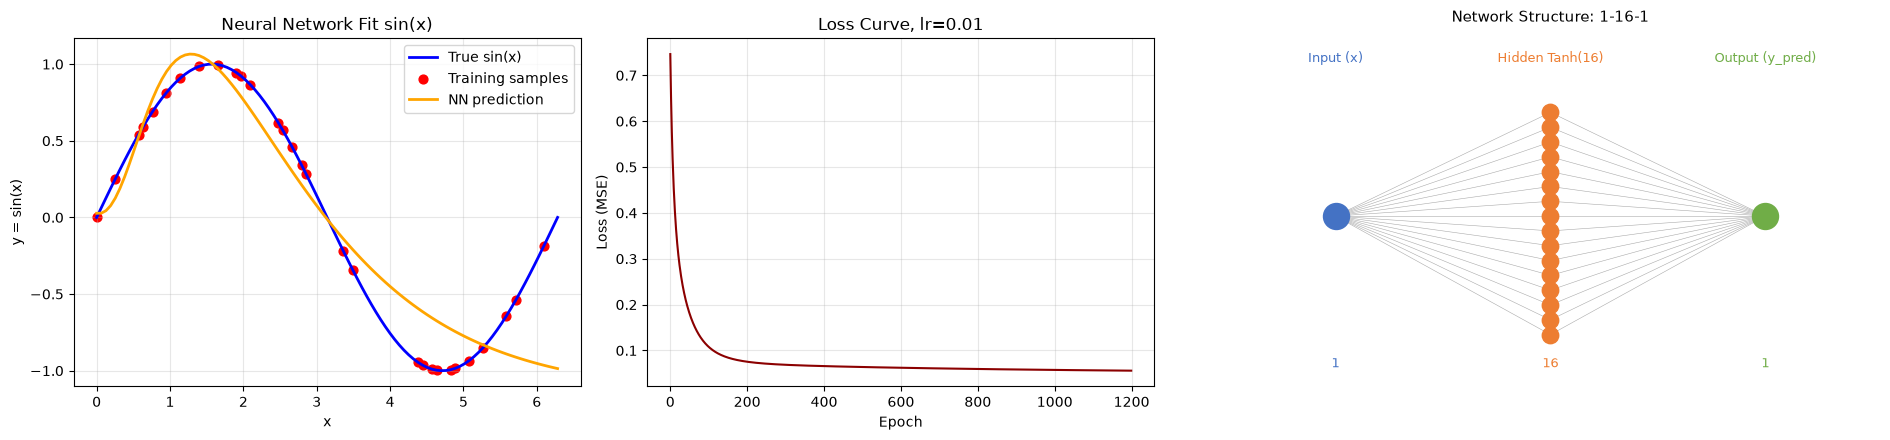

In [18]:
# 导入数值计算库numpy，用于矩阵运算、生成样本数据
import numpy as np
# 导入绘图库matplotlib，用于绘制拟合曲线、损失曲线、网络结构图
import matplotlib.pyplot as plt

# 设置随机种子42，保证每次运行代码，随机初始化权重、采样训练样本结果完全一致，方便复现
np.random.seed(42)

# ---------------------- 1. 构造正弦数据 ----------------------
# 在0~2π区间均匀生成100个点，作为完整x轴数据
x = np.linspace(0, 2 * np.pi, 100)
# 计算正弦函数真实值，作为标签
y_true = np.sin(x)

# 从0~99索引中，无放回随机选出30个下标，用于抽取训练样本
sample_idx = np.random.choice(range(100), size=30, replace=False)
# 根据随机下标取出对应的x，reshape转为N×1列向量，神经网络输入要求二维数组
x_train = x[sample_idx].reshape(-1, 1)
# 根据随机下标取出对应的正弦标签，转为N×1列向量
y_train = y_true[sample_idx].reshape(-1, 1)

# ---------------------- 2. 手写两层神经网络 ----------------------
class SimpleNN:
    """两层全连接神经网络：输入层1个神经元，隐藏层hidden_size个神经元，输出层1个神经元"""
    def __init__(self, hidden_size=16):
        """
        初始化网络权重与偏置
        :param hidden_size: 隐藏层神经元数量，默认16
        """
        # 输入层→隐藏层权重：维度[输入1,隐藏16]，用标准正态分布随机初始化
        self.w1 = np.random.randn(1, hidden_size)
        # 隐藏层偏置：维度[1,隐藏16]，初始化为全0
        self.b1 = np.zeros((1, hidden_size))
        # 隐藏层→输出层权重：维度[隐藏16,输出1]，标准正态分布随机初始化
        self.w2 = np.random.randn(hidden_size, 1)
        # 输出层偏置：维度[1,输出1]，初始化为全0
        self.b2 = np.zeros((1, 1))

    def tanh(self, z):
        """激活函数tanh，双曲正切，输出范围(-1,1)，用于隐藏层非线性变换"""
        return np.tanh(z)

    def forward(self, x):
        """
        前向传播：输入x，经过网络计算得到预测输出
        :param x: 输入数据，N×1
        :return out: 网络预测输出 N×1
        """
        # 输入乘权重+偏置，过tanh激活，得到隐藏层输出，保存为成员变量，反向传播要用
        self.h = self.tanh(np.dot(x, self.w1) + self.b1)
        # 隐藏层输出乘第二层权重+输出层偏置，得到最终预测值（输出层无激活）
        out = np.dot(self.h, self.w2) + self.b2
        return out

    def train(self, x_train, y_train, epochs=1200, lr=0.01):
        """
        训练函数：梯度下降反向传播更新权重
        :param x_train:训练输入
        :param y_train:训练标签
        :param epochs:迭代轮数
        :param lr:学习率
        :return loss_history:每一轮损失值列表，用于后续画损失曲线
        """
        # 保存每一轮损失，用于绘图
        loss_history = []

        # 循环epochs轮，迭代训练网络
        for epoch in range(epochs):
            # 前向传播，得到当前网络预测
            y_pred = self.forward(x_train)
            # 计算MSE均方误差损失，预测值和真实标签的误差平方求均值
            loss = np.mean((y_pred - y_train) ** 2)
            # 将本轮损失存入列表
            loss_history.append(loss)

            # --------反向传播求梯度--------
            # 输出层损失对网络输出的导数
            d_out = 2 * (y_pred - y_train) / len(x_train)
            # 损失对w2的梯度：隐藏层输出转置点乘d_out
            dw2 = np.dot(self.h.T, d_out)
            # 损失对b2的梯度，按样本维度求和，保持二维数组
            db2 = np.sum(d_out, axis=0, keepdims=True)

            # 链式求导，得到损失对隐藏层输出的梯度；(1‑h²)是tanh激活函数导数
            dh = np.dot(d_out, self.w2.T) * (1 - self.h ** 2)
            # 损失对w1的梯度，训练输入转置点乘dh
            dw1 = np.dot(x_train.T, dh)
            # 损失对b1的梯度，样本维度求和，保持二维数组
            db1 = np.sum(dh, axis=0, keepdims=True)

            # 梯度下降更新权重：w = w - lr *梯度
            self.w1 -= lr * dw1
            self.b1 -= lr * db1
            self.w2 -= lr * dw2
            self.b2 -= lr * db2

            # 每200轮打印一次训练状态，观察loss下降
            if epoch % 200 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")
        # 返回全部轮次的损失记录
        return loss_history

#=======================================================  请修改学习率，观测对结果的影响  =============================================================
lr = 0.01     # 依次试验0.01、0.001、0.0001，比较一下
#=====================================================================================================================================================

# 实例化网络，隐藏层神经元16
model = SimpleNN(hidden_size=16)
# 打印训练开始提示，输出学习率
print(f"\n===== Training start, learning rate lr = {lr} =====")
# 调用训练函数，训练1200轮，得到每轮损失
loss_history = model.train(x_train, y_train, epochs=1200, lr=lr)
# 用全部x做前向传播，拿到网络对完整正弦曲线的拟合结果，用于绘图
y_pred = model.forward(x.reshape(-1, 1))



# ---------------------- 3. 绘图：拟合曲线 + 损失曲线 + 网络结构 ----------------------
# 创建画布，画布总尺寸宽19英寸，高4.5英寸
fig = plt.figure(figsize=(19, 4.5))
# 创建网格布局：1行3列，设置宽度比例，第三列加宽给网络结构图
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.3])

# 获取第一个子图对象：拟合曲线图
ax1 = fig.add_subplot(gs[0, 0])
# 获取第二个子图对象：损失曲线图
ax2 = fig.add_subplot(gs[0, 1])
# 获取第三个子图对象：网络结构图
ax3 = fig.add_subplot(gs[0, 2])

# =========左图：正弦拟合=========
# 绘制真实sin(x)蓝色实线
ax1.plot(x, y_true, "b-", label="True sin(x)", linewidth=2)
# 绘制训练样本，红色散点
ax1.scatter(x_train, y_train, c="red", s=40, label="Training samples")
# 绘制神经网络预测拟合曲线，橙色实线
ax1.plot(x, y_pred, "orange", linewidth=2, label="NN prediction")
# 设置x轴标签
ax1.set_xlabel("x")
# 设置y轴标签
ax1.set_ylabel("y = sin(x)")
# 设置子图标题
ax1.set_title("Neural Network Fit sin(x)")
# 显示图例
ax1.legend()
# 绘制网格，透明度0.3，不刺眼
ax1.grid(alpha=0.3)

# =========中图：损失曲线=========
# 绘制损失历史，深红色线条
ax2.plot(loss_history, color="darkred")
# 设置x轴标签
ax2.set_xlabel("Epoch")
# 设置y轴标签
ax2.set_ylabel("Loss (MSE)")
# 设置子图标题，带上学习率
ax2.set_title(f"Loss Curve, lr={lr}")
# 绘制网格
ax2.grid(alpha=0.3)

# =========右图：神经网络结构绘图函数=========
def draw_nn_structure(ax, hidden_size=16):
    """
    在传入的子图ax上绘制网络结构图
    :param ax:matplotlib子图对象
    :param hidden_size:隐藏层神经元数目
    """
    # 设置x轴绘图范围，左右留出边距
    ax.set_xlim(-0.8, 3.8)
    # 设置y轴范围，向下扩大画布空间，解决底部节点与文字重叠问题
    ax.set_ylim(-3.5, hidden_size + 4)
    # 关闭坐标轴刻度、边框，只画网络节点连线
    ax.axis("off")

    # 定义三层在x轴上的位置：输入层、隐藏层、输出层
    x_layer = [0, 1.5, 3.0]

    # --------输入层绘制--------
    # 输入层只有1个神经元，y坐标垂直居中
    y_in = [hidden_size / 2]
    # 绘制输入层蓝色圆点，zorder=10保证圆点画在线条上方，不被连线盖住
    ax.scatter([x_layer[0]], y_in, s=350, color="#4472C4", zorder=10)

    # --------隐藏层绘制--------
    # 在y方向均匀分布16个神经元的y坐标
    y_hidden = np.linspace(0, hidden_size - 1, hidden_size)
    # 绘制隐藏层橙色圆点，缩小s尺寸，防止圆点向下溢出和文字重叠
    ax.scatter([x_layer[1]] * hidden_size, y_hidden, s=140, color="#ED7D31", zorder=10)

    # --------输出层绘制--------
    # 输出层1个神经元，y坐标垂直居中
    y_out = [hidden_size / 2]
    # 绘制输出层绿色圆点
    ax.scatter([x_layer[2]], y_out, s=350, color="#70AD47", zorder=10)

    # --------绘制输入层到隐藏层全部连线--------
    for y1 in y_in:
        for y2 in y_hidden:
            ax.plot([x_layer[0], x_layer[1]], [y1, y2], color="#aaaaaa", linewidth=0.4)
    # --------绘制隐藏层到输出层全部连线--------
    for y1 in y_hidden:
        for y2 in y_out:
            ax.plot([x_layer[1], x_layer[2]], [y1, y2], color="#aaaaaa", linewidth=0.4)

    # 设置子图标题，pad增加标题上方留白
    ax.set_title("Network Structure: 1-16-1", fontsize=11, pad=12)

    # 在每层上方写层名称文本，ha="center"水平居中
    ax.text(x_layer[0], hidden_size + 2.4, "Input (x)",
            ha="center", fontsize=9, color="#4472C4")
    ax.text(x_layer[1], hidden_size + 2.4, "Hidden Tanh(16)",
            ha="center", fontsize=9, color="#ED7D31")
    ax.text(x_layer[2], hidden_size + 2.4, "Output (y_pred)",
            ha="center", fontsize=9, color="#70AD47")

    # 每层底部标注神经元数量，y=-2.2，放到画布底部远离节点圆点
    ax.text(x_layer[0], -2.2, "1", ha="center", fontsize=9, color="#4472C4")
    ax.text(x_layer[1], -2.2, "16", ha="center", fontsize=9, color="#ED7D31")
    ax.text(x_layer[2], -2.2, "1", ha="center", fontsize=9, color="#70AD47")

# 调用绘图函数，在ax3绘制1‑16‑1网络结构图
draw_nn_structure(ax3, hidden_size=16)

# 自动调整布局，防止子图、标题互相挤压重叠
plt.tight_layout()
# 弹出窗口显示全部图像
plt.show()